# Real Data Predictive Performance

This notebook compares the performance of the EM approach to ridge regression with LOO-CV on real datasets across polynomial expansion degrees d=1, 2, 3.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from plotting import scatter_clipped, grid_with_colourbar
from experiments import Experiment, fitting_time, prediction_r2, number_of_features
from journal2026 import (
    JOURNAL2026_TRAIN_SIZES,
    JOURNAL2026_D1_TINY,   JOURNAL2026_D2_TINY,   JOURNAL2026_D3_TINY,
    JOURNAL2026_D1_SMALL,  JOURNAL2026_D2_SMALL,  JOURNAL2026_D3_SMALL,
    JOURNAL2026_D1_MEDIUM, JOURNAL2026_D2_MEDIUM, JOURNAL2026_D3_MEDIUM,
    JOURNAL2026_D1_LARGE,  JOURNAL2026_D2_LARGE,
    JOURNAL2026_ESTIMATORS, JOURNAL2026_EST_NAMES,
)

JOURNAL2026_ESTIMATORS

[RidgeEM(), RidgeLOOCV(alphas=11), RidgeLOOCV(alphas=101)]

In [2]:
def run_exp(problems):
    return Experiment(
        problems, JOURNAL2026_ESTIMATORS,
        reps=10, ns=[[JOURNAL2026_TRAIN_SIZES[p.dataset]] for p in problems],
        seed=0,
        stats=[fitting_time, prediction_r2, number_of_features],
        est_names=JOURNAL2026_EST_NAMES).run()


def stat_mean(exp, stat_name, est_name, problem_idx):
    j = exp.est_names.index(est_name)
    return np.nanmean(getattr(exp, stat_name + '_')[:, problem_idx, 0, j])


def result_table(exp):
    rows = []
    for i, problem in enumerate(exp.problems):
        em_time = stat_mean(exp, 'fitting_time', 'EM', i)
        cv_time = stat_mean(exp, 'fitting_time', 'CV_glm_101', i)
        row = {
            'dataset': problem.dataset,
            'target':  ', '.join(problem.target) if isinstance(problem.target, tuple)
                       else problem.target,
        }
        row.update({est: stat_mean(exp, 'prediction_r2', est, i) for est in exp.est_names})
        row['Speed-Up'] = cv_time / em_time
        row['p']        = stat_mean(exp, 'number_of_features', 'EM', i)
        row['n_train']  = int(exp.ns[i, 0])
        row['n:p']      = int(exp.ns[i, 0]) / stat_mean(exp, 'number_of_features', 'EM', i)
        rows.append(row)
    return pd.DataFrame(rows).sort_values('n_train', ascending=False).round(2)


def scatter_figure(exps_d1, exps_d2, exps_d3=None):
    col_exps = [exps_d1, exps_d2] + ([exps_d3] if exps_d3 is not None else [])
    ncols = len(col_exps)
    su_all = [
        np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
        for exps in col_exps for e in exps for cv in [1, 2] for i in range(len(e.problems))
    ]
    norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))
    col_titles = ['$d=1$', '$d=2$'] + (['$d=3$'] if exps_d3 is not None else [])
    fig, axes = grid_with_colourbar(
        2, ncols, norm, plt.cm.Greens,
        y_labels=['CV GLM 101 $R^2$', 'CV GLM 11 $R^2$'],
        col_titles=col_titles,
        x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')
    for col, exps in enumerate(col_exps):
        for row, cv in enumerate([2, 1]):
            scatter_clipped(
                np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0) for e in exps]),
                np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0) for e in exps]),
                np.concatenate([np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                                / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0) for e in exps]),
                norm, plt.cm.Greens, ax=axes[row, col])
    return fig

## Tiny Datasets

In [3]:
exp_d1_tiny = run_exp(JOURNAL2026_D1_TINY)

  0%|          | 0/4 [00:00<?, ?it/s]

autompg:   0%|          | 0/30 [00:00<?, ?it/s]

autompg  —  0 computed, 30 retrieved  (0.0s)


diabetes:   0%|          | 0/30 [00:00<?, ?it/s]

diabetes  —  0 computed, 30 retrieved  (0.0s)


real_estate:   0%|          | 0/30 [00:00<?, ?it/s]

real_estate  —  0 computed, 30 retrieved  (0.1s)


yacht:   0%|          | 0/30 [00:00<?, ?it/s]

yacht  —  0 computed, 30 retrieved  (0.1s)


In [4]:
exp_d2_tiny = run_exp(JOURNAL2026_D2_TINY)

  0%|          | 0/4 [00:00<?, ?it/s]

autompg:   0%|          | 0/30 [00:00<?, ?it/s]

autompg  —  0 computed, 30 retrieved  (0.0s)


diabetes:   0%|          | 0/30 [00:00<?, ?it/s]

diabetes  —  0 computed, 30 retrieved  (0.0s)


real_estate:   0%|          | 0/30 [00:00<?, ?it/s]

real_estate  —  0 computed, 30 retrieved  (0.0s)


yacht:   0%|          | 0/30 [00:00<?, ?it/s]

yacht  —  0 computed, 30 retrieved  (0.0s)


In [5]:
exp_d3_tiny = run_exp(JOURNAL2026_D3_TINY)

  0%|          | 0/4 [00:00<?, ?it/s]

autompg:   0%|          | 0/30 [00:00<?, ?it/s]

autompg  —  0 computed, 30 retrieved  (0.0s)


diabetes:   0%|          | 0/30 [00:00<?, ?it/s]

diabetes  —  0 computed, 30 retrieved  (0.0s)


real_estate:   0%|          | 0/30 [00:00<?, ?it/s]

real_estate  —  0 computed, 30 retrieved  (0.0s)


yacht:   0%|          | 0/30 [00:00<?, ?it/s]

yacht  —  0 computed, 30 retrieved  (0.0s)


In [6]:
pd.concat([result_table(exp_d1_tiny), result_table(exp_d2_tiny), result_table(exp_d3_tiny)])

,dataset,target,EM,CV_glm_11,CV_glm_101,Speed-Up,p,n_train,n:p
1,diabetes,target,0.50,0.50,0.50,5.12,10.0,309,30.90
2,real_estate,Y house price of unit area,0.59,0.59,0.59,5.05,6.0,289,48.17
0,autompg,mpg,0.81,0.81,0.81,3.97,7.0,274,39.14
3,yacht,Residuary_resistance,0.62,0.62,0.62,5.39,6.0,215,35.83
1,diabetes,target,0.48,0.48,0.48,2.72,65.0,309,4.75
2,real_estate,Y house price of unit area,0.69,0.70,0.70,3.18,27.0,289,10.70
0,autompg,mpg,0.86,0.86,0.86,2.52,35.0,274,7.83
3,yacht,Residuary_resistance,0.91,0.91,0.91,4.25,27.0,215,7.96
1,diabetes,target,0.42,0.41,0.41,1.88,285.0,309,1.08
2,real_estate,Y house price of unit area,0.70,0.70,0.70,1.94,83.0,289,3.48


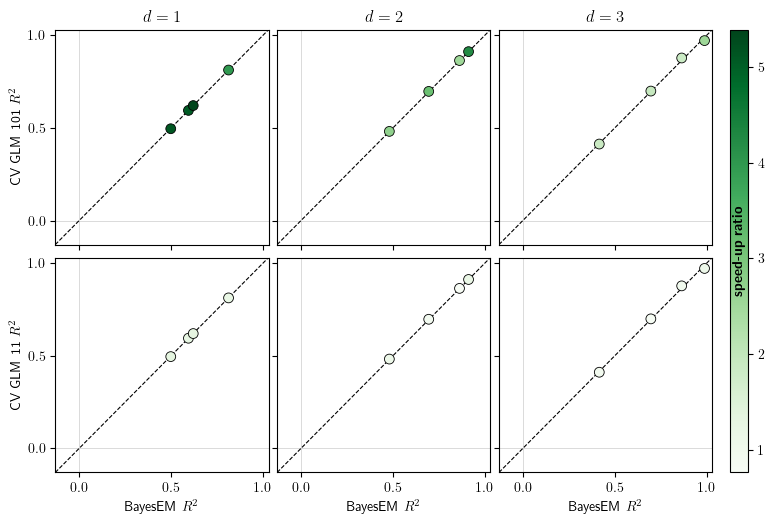

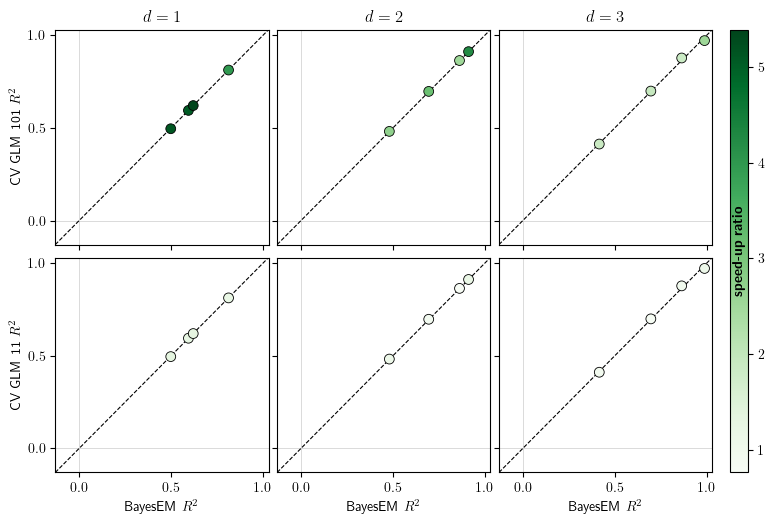

In [7]:
scatter_figure([exp_d1_tiny], [exp_d2_tiny], [exp_d3_tiny])

## Small Datasets

In [8]:
exp_d1_small = run_exp(JOURNAL2026_D1_SMALL)

  0%|          | 0/6 [00:00<?, ?it/s]

airfoil:   0%|          | 0/30 [00:00<?, ?it/s]

airfoil  —  30 computed, 0 retrieved  (0.1s)


automobile:   0%|          | 0/30 [00:00<?, ?it/s]

automobile  —  30 computed, 0 retrieved  (0.1s)


...

concrete  —  30 computed, 0 retrieved  (0.1s)


facebook:   0%|          | 0/30 [00:00<?, ?it/s]

facebook  —  30 computed, 0 retrieved  (0.1s)


forest:   0%|          | 0/30 [00:00<?, ?it/s]

forest  —  30 computed, 0 retrieved  (0.1s)


In [9]:
exp_d2_small = run_exp(JOURNAL2026_D2_SMALL)

  0%|          | 0/6 [00:00<?, ?it/s]

airfoil:   0%|          | 0/30 [00:00<?, ?it/s]

airfoil  —  30 computed, 0 retrieved  (0.1s)


automobile:   0%|          | 0/30 [00:00<?, ?it/s]

automobile  —  30 computed, 0 retrieved  (0.3s)


...

concrete  —  30 computed, 0 retrieved  (0.1s)


facebook:   0%|          | 0/30 [00:00<?, ?it/s]

facebook  —  30 computed, 0 retrieved  (0.3s)


forest:   0%|          | 0/30 [00:00<?, ?it/s]

forest  —  30 computed, 0 retrieved  (0.5s)


In [10]:
exp_d3_small = run_exp(JOURNAL2026_D3_SMALL)

  0%|          | 0/6 [00:00<?, ?it/s]

airfoil:   0%|          | 0/30 [00:00<?, ?it/s]

airfoil  —  30 computed, 0 retrieved  (0.2s)


automobile:   0%|          | 0/30 [00:00<?, ?it/s]

automobile  —  30 computed, 0 retrieved  (2.3s)


...

concrete  —  30 computed, 0 retrieved  (0.3s)


facebook:   0%|          | 0/30 [00:00<?, ?it/s]

facebook  —  30 computed, 0 retrieved  (0.8s)


forest:   0%|          | 0/30 [00:00<?, ?it/s]

forest  —  30 computed, 0 retrieved  (2.0s)


In [11]:
pd.concat([result_table(exp_d1_small), result_table(exp_d2_small), result_table(exp_d3_small)])

,dataset,target,EM,CV_glm_11,CV_glm_101,Speed-Up,p,n_train,n:p
0,airfoil,scaled-sound-pressure,0.50,0.50,0.50,7.10,5.0,1052,210.40
3,concrete,Concrete compressive strength,0.61,0.61,0.61,7.56,8.0,721,90.12
5,forest,area,-0.14,-0.29,-0.29,0.98,26.4,361,13.67
2,boston,medv,0.72,0.72,0.72,4.97,13.0,354,27.23
4,facebook,"comment, like, share",0.26,0.24,0.24,3.51,17.0,349,20.53
1,automobile,price,0.88,0.88,0.88,2.73,49.9,111,2.22
0,airfoil,scaled-sound-pressure,0.62,0.62,0.62,5.39,20.0,1052,52.60
3,concrete,Concrete compressive strength,0.78,0.78,0.78,4.10,44.0,721,16.39
5,forest,area,-0.14,-0.67,-0.67,0.64,295.2,361,1.22
2,boston,medv,0.85,0.85,0.85,2.15,104.0,354,3.40


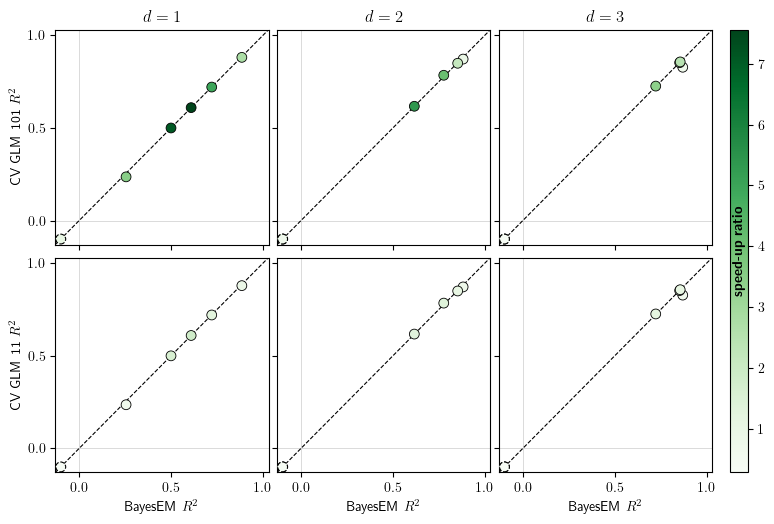

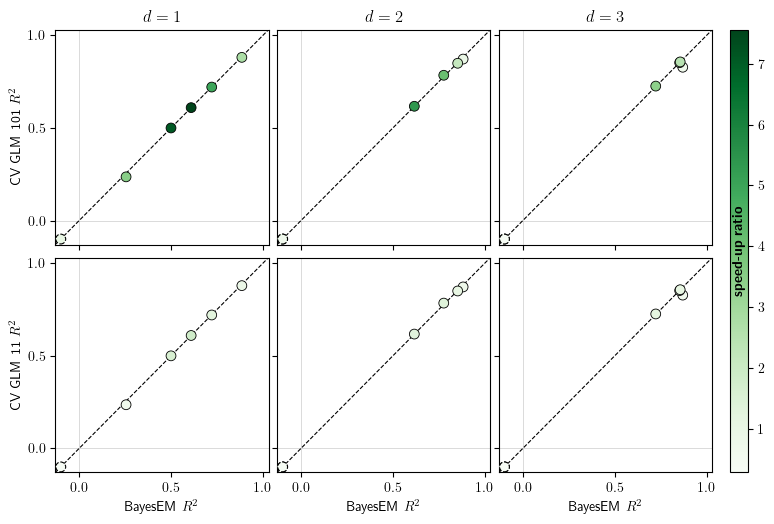

In [12]:
scatter_figure([exp_d1_small], [exp_d2_small], [exp_d3_small])

## Medium Datasets

In [13]:
exp_d1_medium = run_exp(JOURNAL2026_D1_MEDIUM)

  0%|          | 0/7 [00:00<?, ?it/s]

abalone:   0%|          | 0/30 [00:00<?, ?it/s]

abalone  —  30 computed, 0 retrieved  (0.1s)


crime:   0%|          | 0/30 [00:00<?, ?it/s]

crime  —  30 computed, 0 retrieved  (0.4s)


...

naval_propulsion  —  30 computed, 0 retrieved  (0.3s)


parkinsons:   0%|          | 0/30 [00:00<?, ?it/s]

parkinsons  —  30 computed, 0 retrieved  (0.2s)


student:   0%|          | 0/30 [00:00<?, ?it/s]

student  —  30 computed, 0 retrieved  (0.2s)


In [14]:
exp_d2_medium = run_exp(JOURNAL2026_D2_MEDIUM)

  0%|          | 0/6 [00:00<?, ?it/s]

abalone:   0%|          | 0/30 [00:00<?, ?it/s]

abalone  —  30 computed, 0 retrieved  (0.3s)


crime:   0%|          | 0/30 [00:00<?, ?it/s]

crime  —  30 computed, 0 retrieved  (17.5s)


...

naval_propulsion  —  30 computed, 0 retrieved  (1.9s)


parkinsons:   0%|          | 0/30 [00:00<?, ?it/s]

parkinsons  —  30 computed, 0 retrieved  (1.4s)


student:   0%|          | 0/30 [00:00<?, ?it/s]

student  —  30 computed, 0 retrieved  (1.0s)


In [15]:
exp_d3_medium = run_exp(JOURNAL2026_D3_MEDIUM)

  0%|          | 0/5 [00:00<?, ?it/s]

abalone:   0%|          | 0/30 [00:00<?, ?it/s]

abalone  —  30 computed, 0 retrieved  (1.0s)


crime:   0%|          | 0/30 [00:00<?, ?it/s]

crime  —  30 computed, 0 retrieved  (76.7s)


...

naval_propulsion  —  30 computed, 0 retrieved  (15.6s)


parkinsons:   0%|          | 0/30 [00:00<?, ?it/s]

parkinsons  —  30 computed, 0 retrieved  (18.7s)


student:   0%|          | 0/30 [00:00<?, ?it/s]

student  —  30 computed, 0 retrieved  (6.4s)


In [16]:
pd.concat([result_table(exp_d1_medium), result_table(exp_d2_medium), result_table(exp_d3_medium)])

,dataset,target,EM,CV_glm_11,CV_glm_101,Speed-Up,p,n_train,n:p
4,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",0.88,0.88,0.88,7.42,15.0,8353,556.87
5,parkinsons,"motor_UPDRS, total_UPDRS",0.17,0.17,0.17,7.15,19.0,4112,216.42
0,abalone,Rings,0.51,0.51,0.51,8.02,9.0,2923,324.78
1,crime,ViolentCrimesPerPop,0.66,0.66,0.66,2.70,99.0,1395,14.09
6,student,"G1, G2, G3",0.27,0.27,0.27,4.23,39.0,454,11.64
3,eye,y,0.42,0.37,0.37,0.98,200.0,84,0.42
2,ribo,y,0.68,0.68,0.68,0.91,4088.0,49,0.01
3,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",1.00,1.00,1.00,3.21,149.0,8353,56.06
4,parkinsons,"motor_UPDRS, total_UPDRS",0.25,0.23,0.23,2.89,209.0,4112,19.67
0,abalone,Rings,0.32,0.36,0.35,4.49,53.0,2923,55.15


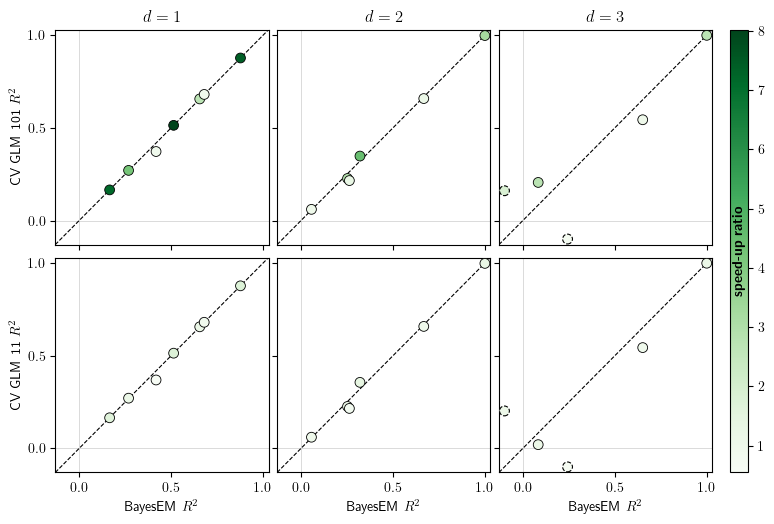

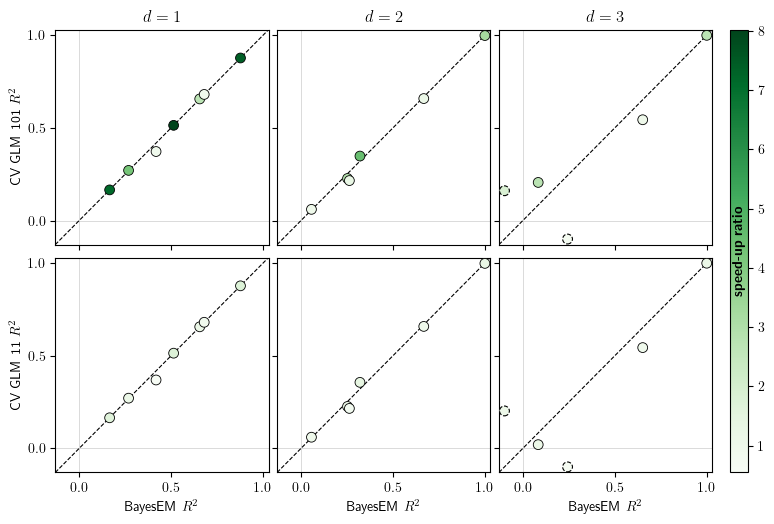

In [17]:
scatter_figure([exp_d1_medium], [exp_d2_medium], [exp_d3_medium])

## Large Datasets

In [18]:
exp_d1_large = run_exp(JOURNAL2026_D1_LARGE)

  0%|          | 0/4 [00:00<?, ?it/s]

twitter:   0%|          | 0/30 [00:00<?, ?it/s]

twitter  —  30 computed, 0 retrieved  (47.4s)


tomshw:   0%|          | 0/30 [00:00<?, ?it/s]

tomshw  —  30 computed, 0 retrieved  (3.1s)


blog:   0%|          | 0/30 [00:00<?, ?it/s]

blog  —  30 computed, 0 retrieved  (15.0s)


ct_slices:   0%|          | 0/30 [00:00<?, ?it/s]

ct_slices  —  30 computed, 0 retrieved  (22.6s)


In [19]:
exp_d2_large = run_exp(JOURNAL2026_D2_LARGE)

  0%|          | 0/4 [00:00<?, ?it/s]

twitter:   0%|          | 0/30 [00:00<?, ?it/s]

twitter  —  30 computed, 0 retrieved  (57.4s)


tomshw:   0%|          | 0/30 [00:00<?, ?it/s]

tomshw  —  30 computed, 0 retrieved  (87.8s)


blog:   0%|          | 0/30 [00:00<?, ?it/s]

blog  —  30 computed, 0 retrieved  (56.6s)


ct_slices:   0%|          | 0/30 [00:00<?, ?it/s]

ct_slices  —  30 computed, 0 retrieved  (60.6s)


In [20]:
pd.concat([result_table(exp_d1_large), result_table(exp_d2_large)])

,dataset,target,EM,CV_glm_11,CV_glm_101,Speed-Up,p,n_train,n:p
0,twitter,V78,0.93,0.93,0.93,4.86,77.0,408275,5302.27
3,ct_slices,reference,0.86,0.86,0.86,3.79,379.7,37450,98.63
2,blog,V281,0.35,0.35,0.35,3.99,276.0,36677,132.89
1,tomshw,V97,0.96,0.96,0.96,3.45,96.0,19725,205.47
0,twitter,V78,0.88,0.88,0.88,5.17,86.0,408275,4747.38
3,ct_slices,reference,0.92,0.92,0.92,2.86,929.1,37450,40.31
2,blog,V281,0.37,0.37,0.37,2.83,884.9,36677,41.45
1,tomshw,V97,0.93,0.97,0.97,2.03,1775.0,19725,11.11


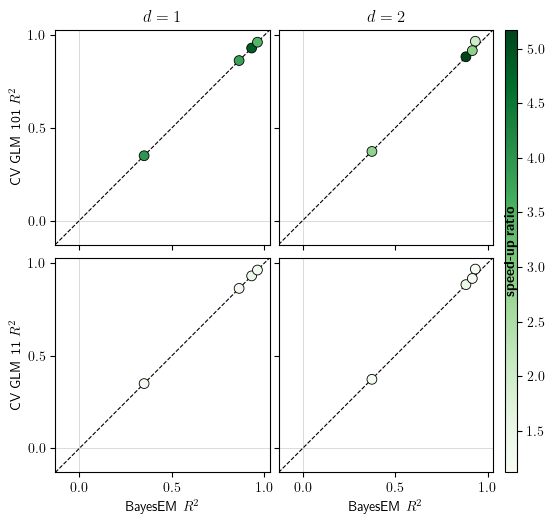

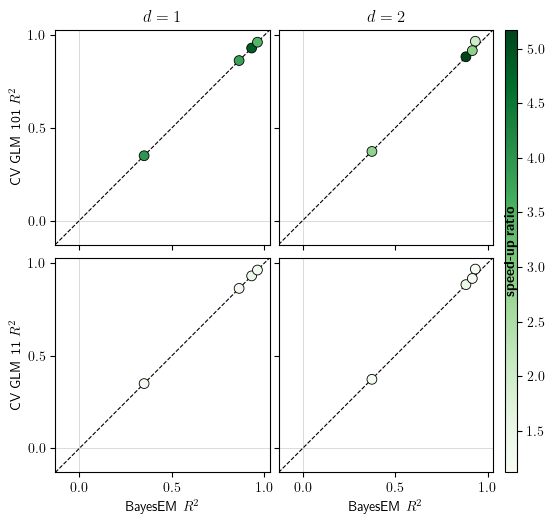

In [21]:
scatter_figure([exp_d1_large], [exp_d2_large])

## Summary

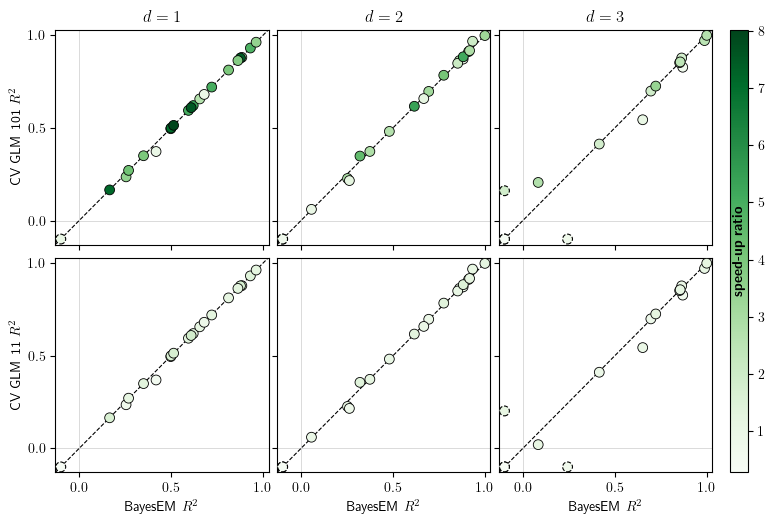

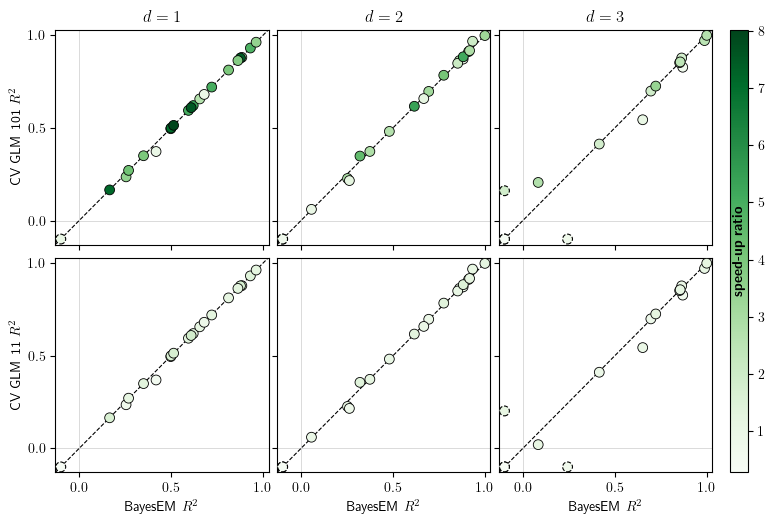

In [22]:
scatter_figure(
    [exp_d1_tiny, exp_d1_small, exp_d1_medium, exp_d1_large],
    [exp_d2_tiny, exp_d2_small, exp_d2_medium, exp_d2_large],
    [exp_d3_tiny, exp_d3_small, exp_d3_medium],
)